# 06_Data Visualization II

하나의 Variable을 분석할 때는 Histogram과 Box Plot을 이용하여 Distribution을 살펴보았다.

이번에는 두 개 이상의 Variable을 함께 살펴본다.

예를 들어 다음과 같은 질문을 생각할 수 있다.

- Income이 높은 지역은 House Value도 높은가?
- House Age와 House Value는 관계가 있는가?
- Room 수가 많은 지역은 House Value가 높은가?
- 어떤 Variable들이 서로 강한 관계를 가지는가?

이러한 관계를 발견하기 위해 다음 방법을 사용한다.

- Scatter Plot
- Pair Plot
- Correlation

> Variables → Visualization → Relationship Discovery

In [1]:
from google.colab import drive

# Google Drive를 Colab에 Mount
drive.mount('/content/drive')

# 강의용 Data가 저장된 Folder

data_path = "/content/drive/My Drive/Colab Notebooks/0_ML/Input/"

Mounted at /content/drive


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# California Housing Data 읽기
df = pd.read_csv(data_path+"california_housing.csv")

# Data 확인
display(df.head())

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Shape: (20640, 9)
Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


## Relationship between Two Variables

두 Numerical Variables 사이의 관계를 알아보기 위해 먼저 각각의 값을 서로 대응시켜 생각해 볼 수 있다.

예를 들어 `MedInc`를 $x$, `MedHouseVal`을 $y$라고 하자.

각 Sample은 하나의 Point로 표현할 수 있다.

$$
(x_i,y_i)
$$

많은 Sample을 좌표평면에 표시하면 두 Variable 사이에 어떤 관계가 있는지 시각적으로 관찰할 수 있다.

이러한 Plot을 Scatter Plot이라고 한다.

In [4]:
# MedInc와 MedHouseVal의 일부 값 확인
display(
    df[["MedInc", "MedHouseVal"]].head(10)
)

,MedInc,MedHouseVal
0,8.3252,4.526
1,8.3014,3.585
2,7.2574,3.521
3,5.6431,3.413
4,3.8462,3.422
5,4.0368,2.697
6,3.6591,2.992
7,3.1200,2.414
8,2.0804,2.267
9,3.6912,2.611


## Scatter Plot

Scatter Plot은 두 Numerical Variables 사이의 관계를 Point로 표현한다.

Scatter Plot에서는 다음과 같은 특징을 관찰할 수 있다.

- 한 Variable이 증가할 때 다른 Variable도 증가하는가?
- 한 Variable이 증가할 때 다른 Variable은 감소하는가?
- 두 Variable 사이에 뚜렷한 관계가 없는가?
- 여러 Group이 존재하는가?
- 다른 Point와 크게 떨어진 Sample이 존재하는가?

먼저 `MedInc`와 `MedHouseVal`의 관계를 살펴보자.

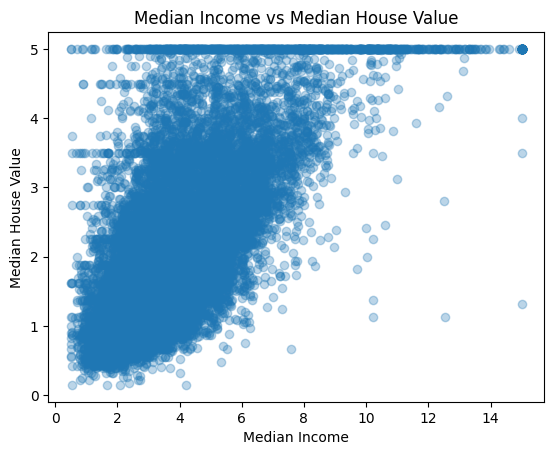

In [6]:
# Median Income과 Median House Value의 관계
plt.scatter(
    df["MedInc"],
    df["MedHouseVal"],
    alpha=0.3
)

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value")

plt.show()

## Interpreting a Scatter Plot

Scatter Plot에서는 Point 하나하나보다 전체적인 Pattern을 관찰하는 것이 중요하다.

두 Variable이 함께 증가하는 경향이 있다면 Positive Relationship이 있다고 볼 수 있다.

한 Variable이 증가할 때 다른 Variable이 감소하는 경향이 있다면 Negative Relationship이 있다고 볼 수 있다.

뚜렷한 증가나 감소 Pattern이 없다면 두 Variable 사이의 관계가 약할 수 있다.

그러나 Scatter Plot에서 관계가 보인다고 해서 한 Variable이 다른 Variable의 원인이라는 의미는 아니다.

> Relationship does not necessarily mean Causation.

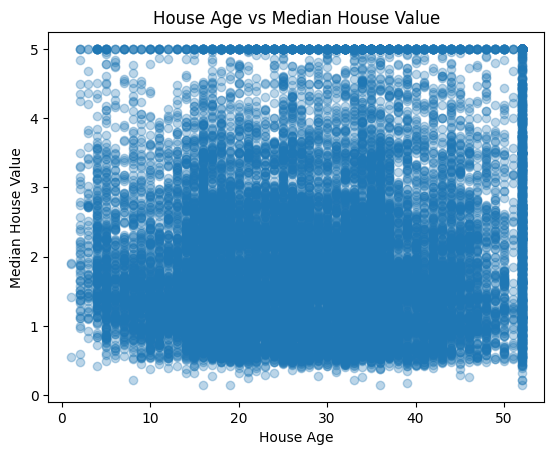

In [7]:
# HouseAge와 MedHouseVal의 관계
plt.scatter(
    df["HouseAge"],
    df["MedHouseVal"],
    alpha=0.3
)

plt.xlabel("House Age")
plt.ylabel("Median House Value")
plt.title("House Age vs Median House Value")

plt.show()

## Comparing Relationships

같은 Output Variable에 대해 여러 Input Variables를 비교할 수 있다.

예를 들어 House Value를 분석하고 싶다면 다음과 같은 질문을 할 수 있다.

`MedInc`, `HouseAge`, `AveRooms` 중 어떤 Variable이 `MedHouseVal`과 더 뚜렷한 관계를 가지는가?

Scatter Plot을 이용하면 이러한 관계를 직접 비교할 수 있다.

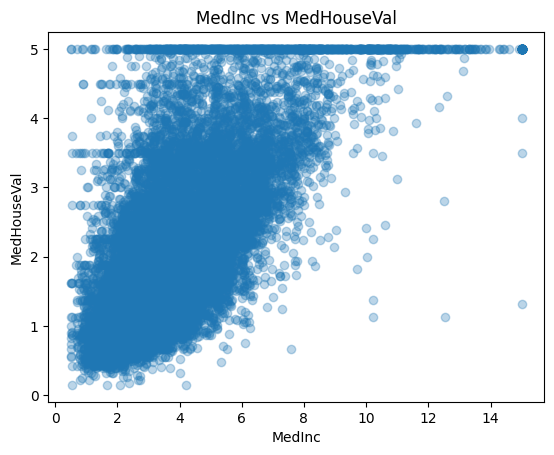

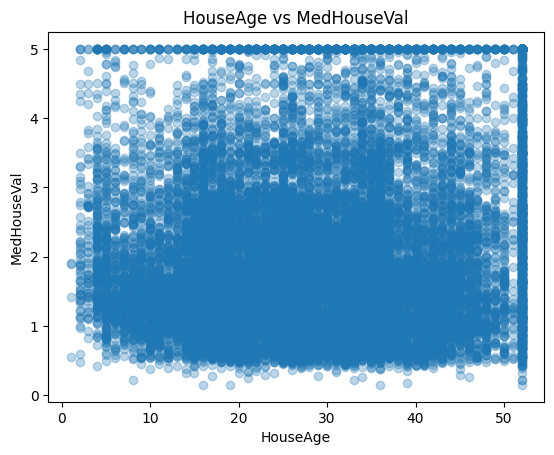

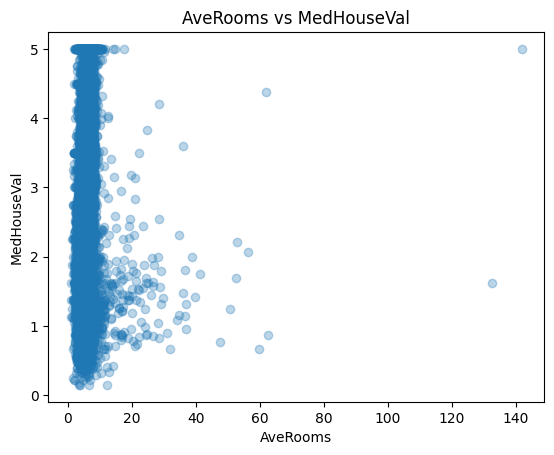

In [8]:
# MedInc와 MedHouseVal
plt.scatter(df["MedInc"], df["MedHouseVal"], alpha=0.3)
plt.xlabel("MedInc")
plt.ylabel("MedHouseVal")
plt.title("MedInc vs MedHouseVal")
plt.show()

# HouseAge와 MedHouseVal
plt.scatter(df["HouseAge"], df["MedHouseVal"], alpha=0.3)
plt.xlabel("HouseAge")
plt.ylabel("MedHouseVal")
plt.title("HouseAge vs MedHouseVal")
plt.show()

# AveRooms와 MedHouseVal
plt.scatter(df["AveRooms"], df["MedHouseVal"], alpha=0.3)
plt.xlabel("AveRooms")
plt.ylabel("MedHouseVal")
plt.title("AveRooms vs MedHouseVal")
plt.show()

## Correlation

Scatter Plot은 두 Variable 사이의 관계를 눈으로 보여준다.

Correlation은 두 Numerical Variables 사이의 Linear Relationship을 하나의 숫자로 나타낸다.

Pearson Correlation Coefficient는 일반적으로 $r$로 나타내며 다음 범위를 가진다.

$$
-1 \le r \le 1
$$

$r$이 1에 가까우면 강한 Positive Linear Relationship을 나타낸다.

$r$이 -1에 가까우면 강한 Negative Linear Relationship을 나타낸다.

$r$이 0에 가까우면 Linear Relationship이 약하다는 것을 의미한다.

In [9]:
# MedInc와 MedHouseVal의 Correlation
r = df["MedInc"].corr(df["MedHouseVal"])

print("Correlation:", r)

Correlation: 0.6880752079585475


## Correlation Matrix

Variable이 많아지면 모든 Variable Pair에 대해 Scatter Plot을 하나씩 그리는 것은 불편하다.

Correlation Matrix를 이용하면 Numerical Variables 사이의 Correlation을 한 번에 계산할 수 있다.

이를 이용하면 어떤 Variable Pair가 강한 Linear Relationship을 가지는지 빠르게 찾을 수 있다.

In [10]:
# 모든 Numerical Variables 사이의 Correlation 계산
corr = df.corr(numeric_only=True)

display(corr)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [11]:
# MedHouseVal과 다른 Variables의 Correlation을 큰 순서대로 확인
house_value_corr = corr["MedHouseVal"].sort_values(
    ascending=False
)

print(house_value_corr)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


## Correlation and Scatter Plot

Correlation 값만 보고 Variable의 관계를 판단해서는 안 된다.

Correlation은 주로 Linear Relationship의 정도를 나타낸다.

따라서 다음과 같은 경우에는 Correlation 값만으로 Data의 특징을 충분히 설명하기 어렵다.

- Nonlinear Relationship
- Outlier
- 여러 Group이 섞여 있는 경우

좋은 Data Analysis에서는 숫자와 Visualization을 함께 확인한다.

> Correlation → Scatter Plot → Interpretation

## Pair Plot

두 Variable씩 Scatter Plot을 반복해서 그리면 여러 Variable 사이의 관계를 한 번에 비교하기 어렵다.

Pair Plot은 여러 Numerical Variables의 관계를 한 화면에서 비교할 수 있도록 한다.

Diagonal에서는 각 Variable의 Distribution을 볼 수 있고, 나머지 위치에서는 Variable Pair의 관계를 볼 수 있다.

Pair Plot을 이용하면 다음과 같은 특징을 탐색할 수 있다.

- Variable 사이의 Relationship
- Group 또는 Cluster
- Outlier
- 특이한 Pattern

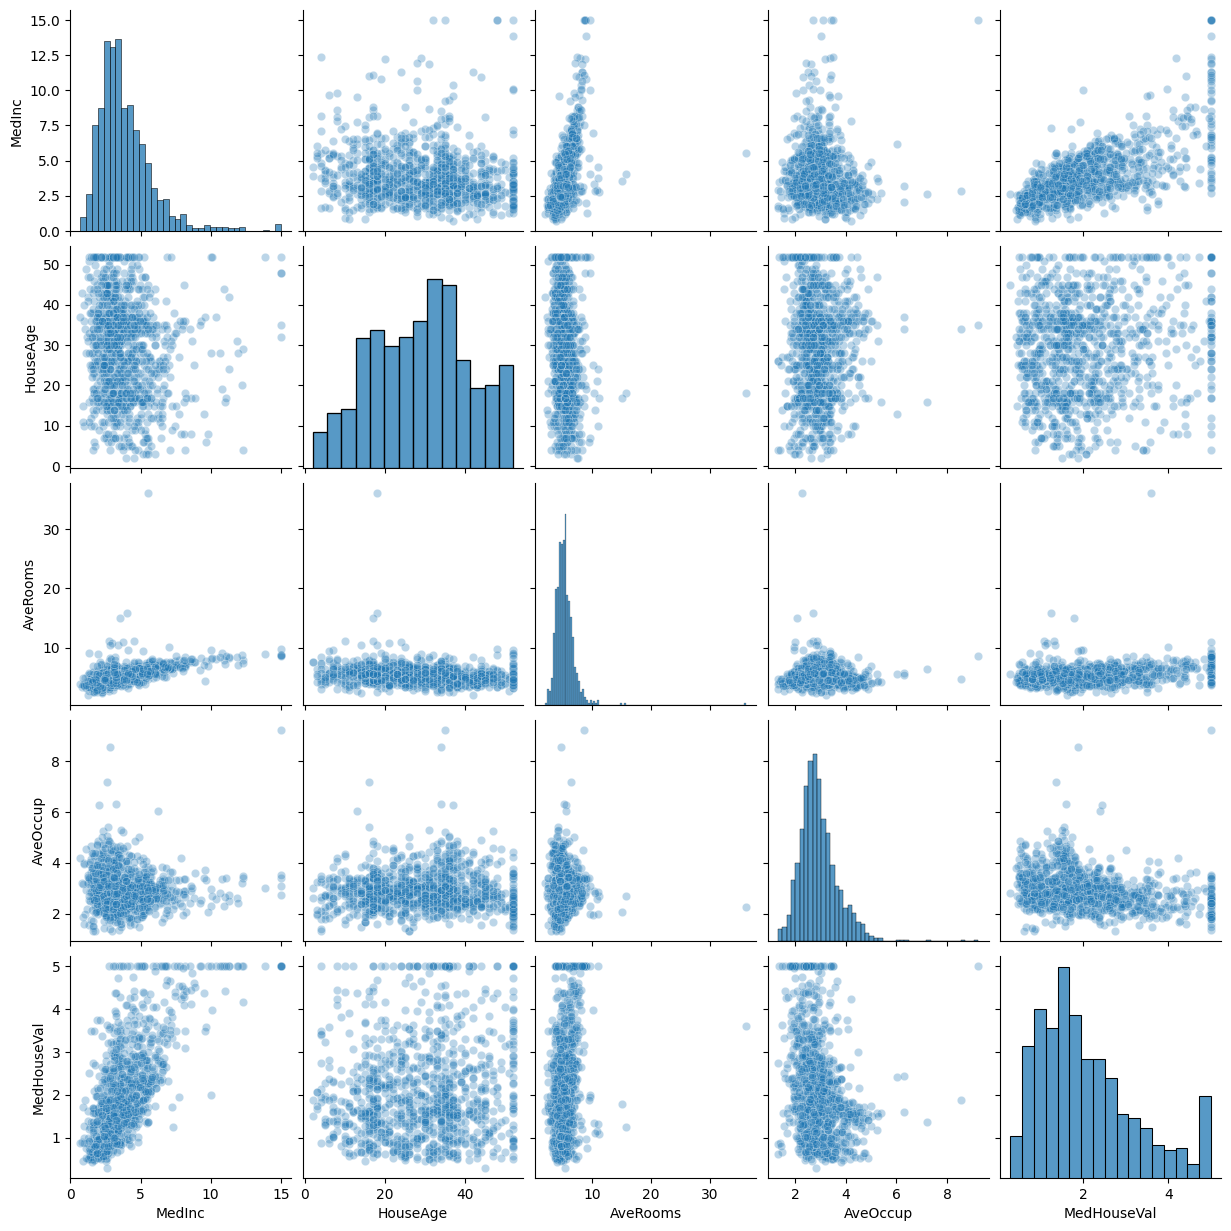

In [12]:
import seaborn as sns

# 분석할 Variables 선택
selected = df[
    ["MedInc", "HouseAge", "AveRooms", "AveOccup", "MedHouseVal"]
]

# Pair Plot
sns.pairplot(
    selected.sample(1000, random_state=42),
    diag_kind="hist",
    plot_kws={"alpha": 0.3}
)

plt.show()

## Why Use a Sample?

California Housing Data에는 많은 Sample이 존재한다.

모든 Sample을 Pair Plot에 표시하면 Point가 지나치게 많아져 Pattern을 관찰하기 어려울 수 있고 Plot을 만드는 데도 시간이 오래 걸린다.

이 경우 일부 Sample을 선택하여 전체적인 Pattern을 먼저 살펴볼 수 있다.

Visualization의 목적은 모든 Data Point를 반드시 화면에 표시하는 것이 아니라 Data의 중요한 특징을 발견하는 것이다.

## Finding Clusters and Outliers

Scatter Plot과 Pair Plot은 단순히 두 Variable의 증가와 감소 관계만 보여주는 것이 아니다.

Point들이 몇 개의 Group으로 나뉘어 보일 수도 있다.

또한 대부분의 Point와 크게 떨어져 있는 Sample을 발견할 수도 있다.

이러한 관찰은 이후 Machine Learning Problem으로 발전할 수 있다.

- Relationship → Regression
- Group → Clustering
- Unusual Point → Outlier Detection

Visualization은 Machine Learning을 적용하기 전에 Problem의 구조를 발견하는 중요한 과정이다.

In [ ]:
# AveRooms와 AveOccup의 관계에서 특이한 Sample 확인
plt.scatter(
    df["AveRooms"],
    df["AveOccup"],
    alpha=0.3
)

plt.xlabel("Average Rooms")
plt.ylabel("Average Occupancy")
plt.title("Average Rooms vs Average Occupancy")

plt.show()

# 값이 큰 Sample을 실제 Data에서 확인
display(
    df.sort_values(
        "AveOccup",
        ascending=False
    ).head(10)
)

## Practice

`california_housing.csv`에서 `MedHouseVal`과 다른 Variables의 관계를 분석한다.

- `MedHouseVal`과 모든 Numerical Variables의 Correlation을 계산한다.
- `MedHouseVal`과 가장 높은 Positive Correlation을 가지는 Variable을 찾는다.
- 두 Variables의 Scatter Plot을 그린다.
- Scatter Plot에서 Relationship의 방향과 강도를 관찰한다.
- 특이한 Pattern이나 Outlier가 존재하는지 확인한다.

Correlation 값과 Scatter Plot에서 관찰한 결과를 함께 비교한다.

MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: MedHouseVal, dtype: float64

Selected Variable: MedInc
Correlation: 0.6880752079585484


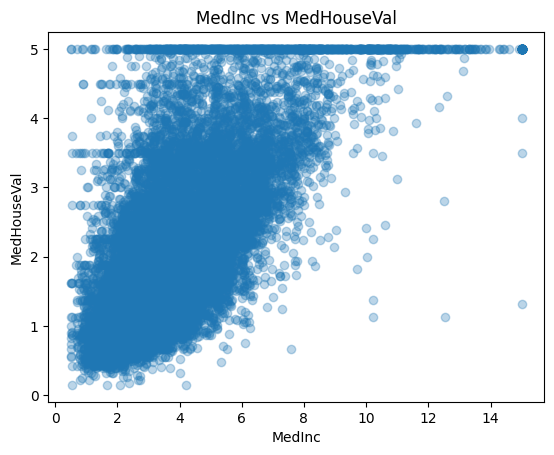

In [13]:
# MedHouseVal과 다른 Variables의 Correlation 계산
corr = df.corr(numeric_only=True)["MedHouseVal"]

# 자기 자신인 MedHouseVal을 제외하고 큰 순서대로 정렬
corr = corr.drop("MedHouseVal").sort_values(ascending=False)

print(corr)

# 가장 높은 Positive Correlation을 가지는 Variable
variable = corr.index[0]

print("\nSelected Variable:", variable)
print("Correlation:", corr.iloc[0])

# 선택된 Variable과 MedHouseVal의 Scatter Plot
plt.scatter(
    df[variable],
    df["MedHouseVal"],
    alpha=0.3
)

plt.xlabel(variable)
plt.ylabel("MedHouseVal")
plt.title(f"{variable} vs MedHouseVal")

plt.show()

### HW_06

`Input/california_housing.csv`를 분석하여 다음 질문에 답하시오.

- `MedHouseVal`을 제외한 Variable 중 `MedHouseVal`과 가장 높은 Positive Correlation을 가지는 Variable Name을 적으시오.
- 위 Variable과 `MedHouseVal` 사이의 Correlation 값을 소수점 셋째 자리까지 적으시오.
- `MedHouseVal`과 가장 높은 Negative Correlation을 가지는 Variable Name을 적으시오.
- 위 Variable과 `MedHouseVal` 사이의 Correlation 값을 소수점 셋째 자리까지 적으시오.
- `AveRooms`와 `AveBedrms` 사이의 Correlation 값을 소수점 셋째 자리까지 적으시오.

답만 제출하시오.